# Stages 5–6 hands-on — usable area, PV yield & suitability (the capstone)

This notebook is `00_pipeline_overview`'s toy, one-roof chain — footprint → usable area → kW →
kWh/yr → CO2/yr — made **real, per roof, across the whole tiny AOI**. Every input it needs was
built by the earlier exploration notebooks:

- **`01_footprints_and_dsm`** — the DSM fetch (stages 1–2) and the DSM-vs-DTM shading trap.
- **`02_radiation_rsun`** — GRASS `r.sun` **annual, shaded** insolation (stage 3): the 12-mid-month
  sampling recipe, run here again to get a real raster instead of re-using numbers.
- **`03_roof_planes`** — RANSAC per-roof **tilt + aspect** (stage 4), with its inlier-ratio /
  pixel-count uncertainty proxy.

New in this notebook: **stage 5** (usable area — a transparent utilization-fraction rule) and
**stage 6** (PV capacity, annual energy, CO2 offset, and a per-roof suitability score). Same tiny,
self-contained AOI as `01`–`03` (a ~400 m slice of Glover Park, buffered 100 m in a metric CRS), so
everything below runs in a couple of minutes and stays inspectable roof-by-roof.

## The plan

1. Fetch the tiny DSM + OSM footprints (condensed from `01`).
2. Run GRASS `r.sun` for 12 mid-month days, shading **on** by default, and sum to an **annual,
   shaded, clear-sky insolation raster** (condensed from `02`).
3. Fit a RANSAC plane per footprint → tilt, aspect, inlier ratio (condensed from `03`) — the base
   per-roof table.
4. **Stage 5** — apply the usable-area rule (flat / pitched-sun-facing / pitched-north-facing) to
   get `usable_area_m2` per roof.
5. **Stage 6** — zonal-mean the shaded insolation raster per roof, derate it to a real-sky
   estimate, and turn usable area + that insolation into capacity (kW), annual energy (kWh/yr),
   and CO2 offset (kg/yr). Score every roof 0–100 by **percentile rank** of energy **density** (not raw kWh), so the
   score actually spreads across roofs.
6. Map the AOI by suitability and by annual energy; print the AOI-wide headline totals.
7. Close with an honest assumptions ledger — this is an order-of-magnitude estimate, not a
   bankable one.

In [1]:
import os
import subprocess
import sys
import tempfile
import warnings
from pathlib import Path
from types import ModuleType

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import osmnx as ox
import planetary_computer as pc
import pyproj
import pystac_client
import rasterio
import rasterio.mask
from rasterio.crs import CRS
from rasterio.features import geometry_mask
from rasterio.merge import merge
from rasterio.transform import from_origin
from rasterio.warp import Resampling, reproject
from shapely.geometry import Polygon, box, mapping
from shapely.ops import transform as shp_transform
from sklearn.linear_model import RANSACRegressor

warnings.filterwarnings("ignore")  # keep the notebook output clean for reading

PC_STAC = "https://planetarycomputer.microsoft.com/api/stac/v1"
WORKING_CRS = "EPSG:6347"  # NAD83(2011) / UTM 18N -- metric, covers DC

# Same tiny AOI as 01/02/03, buffered 100 m in the metric CRS (never in degrees -- trap 2, see 01).
TINY_AOI = (-77.0770, 38.9182, -77.0730, 38.9218)
BUFFER_M = 100.0

core = box(*TINY_AOI)
to_metric = pyproj.Transformer.from_crs("EPSG:4326", WORKING_CRS, always_xy=True).transform
to_lonlat = pyproj.Transformer.from_crs(WORKING_CRS, "EPSG:4326", always_xy=True).transform
core_metric = shp_transform(to_metric, core)
buffered_metric = core_metric.buffer(BUFFER_M)
buffered = shp_transform(to_lonlat, buffered_metric)

# --- shared 2 m target grid over the buffered AOI (same recipe as 01/02/03) ---
dst_crs = CRS.from_string(WORKING_CRS)
minx, miny, maxx, maxy = buffered_metric.bounds
RES = 2.0
width = int(np.ceil((maxx - minx) / RES))
height = int(np.ceil((maxy - miny) / RES))
target_transform = from_origin(minx, maxy, RES, RES)
target_shape = (height, width)
extent = (minx, maxx, miny, maxy)  # matplotlib imshow extent, in metres


def fetch_dsm_to_grid(collection: str, aoi_lonlat: Polygon) -> tuple[np.ndarray, float, int]:
    '''Fetch a 3DEP collection from Planetary Computer and reproject onto the shared 2 m grid.

    Condensed from 01_footprints_and_dsm's `fetch_to_grid` -- see that notebook for the full
    walkthrough of the windowed read and the compound-CRS gotcha. Returns (array, nodata, n_items).
    '''
    cat = pystac_client.Client.open(PC_STAC, modifier=pc.sign_inplace)
    items = list(cat.search(collections=[collection], intersects=mapping(aoi_lonlat)).items())
    srcs = [rasterio.open(it.assets["data"].href) for it in items]
    try:
        nodata = srcs[0].nodata
        hcrs = pyproj.CRS.from_wkt(srcs[0].crs.to_wkt()).sub_crs_list[0]  # drop vertical (NAVD88)
        src_crs = CRS.from_epsg(hcrs.to_epsg())
        to_src = pyproj.Transformer.from_crs("EPSG:4326", hcrs, always_xy=True).transform
        aoi_src = shp_transform(to_src, aoi_lonlat)
        mosaic, mosaic_t = merge(srcs, bounds=aoi_src.bounds)  # windowed read, not whole tiles
    finally:
        for s in srcs:
            s.close()

    dst = np.full(target_shape, nodata, dtype=mosaic.dtype)
    reproject(
        mosaic[0], dst,
        src_transform=mosaic_t, src_crs=src_crs,
        dst_transform=target_transform, dst_crs=dst_crs,
        src_nodata=nodata, dst_nodata=nodata, resampling=Resampling.bilinear,
    )
    return dst, nodata, len(items)


dsm, dsm_nodata, n_dsm = fetch_dsm_to_grid("3dep-lidar-dsm", buffered)
print(f"DSM: grid {dsm.shape} @ {RES:.0f} m, mosaicked from {n_dsm} STAC item(s)")

osm = ox.features_from_polygon(buffered, {"building": True})
footprints = osm[osm.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].reset_index(drop=True)
footprints_m = footprints.to_crs(WORKING_CRS)
print(f"{len(footprints_m)} building footprints in the buffered tiny AOI")

DSM: grid (304, 278) @ 2 m, mosaicked from 3 STAC item(s)
1001 building footprints in the buffered tiny AOI


Annual shaded insolation (clear-sky, 12-day sample, GRASS r.sun -- condensed from 02):
  mean 1827  min 207  max 2626  kWh/m2/yr (clear-sky)


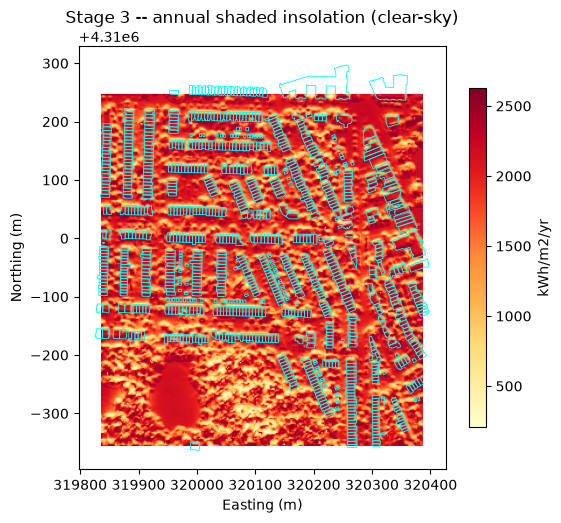

In [2]:
# --- Stage 3 (condensed from 02) -- GRASS r.sun, annual shaded, clear-sky insolation --------
# Throwaway GRASS location + all scratch GeoTIFFs live under tempfile dirs -- nothing here
# touches the repo tree (see 02 for the full location/mapset walkthrough).

def start_grass_session(epsg: str, gisdb: str) -> ModuleType:
    '''Create a throwaway GRASS location bound to `epsg` inside `gisdb` and initialise a session.

    Returns the `grass.script` module, ready to call (gs.run_command, gs.read_command, ...).
    '''
    gisbase = subprocess.run(
        ["grass", "--config", "path"], capture_output=True, text=True, check=True
    ).stdout.strip()
    os.environ["GISBASE"] = gisbase
    sys.path.insert(0, os.path.join(gisbase, "etc", "python"))

    import grass.script as gs
    from grass.script import setup as gsetup

    location = os.path.join(gisdb, "solar")
    subprocess.run(["grass", "-e", "-c", epsg, location], check=True, capture_output=True, text=True)
    gsetup.init(os.path.join(location, "PERMANENT"))
    return gs


def write_geotiff(path: str, array: np.ndarray, nodata: float) -> None:
    '''Write `array` to `path` as a single-band GeoTIFF on the shared target grid.'''
    profile = {
        "driver": "GTiff", "dtype": array.dtype, "count": 1, "nodata": nodata,
        "width": target_shape[1], "height": target_shape[0],
        "crs": dst_crs, "transform": target_transform,
    }
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(array, 1)


def masked(arr: np.ndarray, nodata: float | None) -> np.ndarray:
    '''Copy with nodata -> NaN so it plots transparent and stays out of stats.'''
    out = arr.astype("float32").copy()
    if nodata is not None:
        out[arr == nodata] = np.nan
    return out


def run_r_sun(gs: ModuleType, day: int, workdir: str) -> tuple[np.ndarray, float | None]:
    '''Run r.sun mode 2 for one day (shading ON, the default) and read glob_rad back.

    Exports via a direct `subprocess` call (not gs.run_command) -- r.out.gdal's attempt to carry
    r.sun's GRASS colour table into the Float32 GeoTIFF logs a benign GDAL warning otherwise; the
    raster values are correct either way (see 02). Returns (array, nodata).
    '''
    out_name = f"glob_rad_{day}"
    gs.run_command(
        "r.sun", elevation="dsm", aspect="aspect", slope="slope",
        day=day, glob_rad=out_name, overwrite=True, quiet=True,
    )
    tif_path = f"{workdir}/{out_name}.tif"
    subprocess.run(
        ["r.out.gdal", f"input={out_name}", f"output={tif_path}", "format=GTiff",
         "--overwrite", "--quiet"],
        env=os.environ, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True,
    )
    with rasterio.open(tif_path) as src:
        arr = src.read(1)
        nodata = src.nodata
    return arr, nodata


gisdb = tempfile.mkdtemp(prefix="grassdata_")  # all GRASS data lives here, never in the repo
rsun_workdir = tempfile.mkdtemp(prefix="rsun_")  # scratch GeoTIFFs (DSM in, r.sun outputs out)

dsm_tif_path = os.path.join(rsun_workdir, "dsm.tif")
write_geotiff(dsm_tif_path, dsm, dsm_nodata)

gs = start_grass_session(WORKING_CRS, gisdb)
gs.run_command("r.in.gdal", input=dsm_tif_path, output="dsm", overwrite=True, quiet=True)
gs.run_command("g.region", raster="dsm")
gs.run_command("r.slope.aspect", elevation="dsm", slope="slope", aspect="aspect", overwrite=True, quiet=True)

MID_MONTH_DAYS = [15, 45, 74, 105, 135, 162, 198, 228, 258, 288, 319, 349]
DAYS_IN_MONTH = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

annual_wh = np.zeros(target_shape, dtype="float64")
annual_nodata_mask = np.zeros(target_shape, dtype=bool)

for doy, n_days in zip(MID_MONTH_DAYS, DAYS_IN_MONTH):
    day_arr, day_nodata = run_r_sun(gs, doy, rsun_workdir)
    day_f = masked(day_arr, day_nodata)
    annual_nodata_mask |= np.isnan(day_f)
    annual_wh += np.nan_to_num(day_f) * n_days

annual_kwh_m2 = annual_wh / 1000.0  # Wh -> kWh
annual_kwh_m2[annual_nodata_mask] = np.nan

print("Annual shaded insolation (clear-sky, 12-day sample, GRASS r.sun -- condensed from 02):")
print(f"  mean {np.nanmean(annual_kwh_m2):.0f}  min {np.nanmin(annual_kwh_m2):.0f}  "
      f"max {np.nanmax(annual_kwh_m2):.0f}  kWh/m2/yr (clear-sky)")

fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(annual_kwh_m2, extent=extent, origin="upper", cmap="YlOrRd")
footprints_m.boundary.plot(ax=ax, edgecolor="cyan", lw=0.6)
fig.colorbar(im, ax=ax, shrink=0.8, label="kWh/m2/yr")
ax.set_title("Stage 3 -- annual shaded insolation (clear-sky)")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)"); plt.show()

In [3]:
# --- Stage 4 (condensed from 03) -- RANSAC single-plane tilt/aspect per footprint -----------
MIN_PX = 6  # below this many DSM pixels, don't trust a plane fit at all

roofplanes_workdir = tempfile.mkdtemp(prefix="roofplanes_")
dsm_path = Path(roofplanes_workdir) / "dsm.tif"
with rasterio.open(dsm_path, "w", **{
    "driver": "GTiff", "dtype": dsm.dtype, "count": 1, "nodata": dsm_nodata,
    "width": target_shape[1], "height": target_shape[0],
    "crs": dst_crs, "transform": target_transform,
}) as dst:
    dst.write(dsm, 1)


def roof_points(
    geom: Polygon, dsm_path: Path
) -> tuple[npt.NDArray[np.float64], npt.NDArray[np.float64]]:
    '''Clip the DSM to `geom` and return the roof's raw point cloud (X=(n,2) easting/northing, z=(n,)).'''
    with rasterio.open(dsm_path) as src:
        out_image, out_transform = rasterio.mask.mask(src, [mapping(geom)], crop=True)
        nodata = src.nodata
    band = out_image[0]
    rows, cols = np.where(band != nodata)
    if rows.size == 0:
        return np.empty((0, 2)), np.empty((0,))
    xs, ys = rasterio.transform.xy(out_transform, rows, cols)
    X = np.column_stack([xs, ys]).astype(np.float64)
    z = band[rows, cols].astype(np.float64)
    return X, z


def fit_roof_plane(
    X: npt.NDArray[np.float64], z: npt.NDArray[np.float64]
) -> dict[str, object]:
    '''Fit one RANSAC plane z = a*x + b*y + c to a roof's point cloud.

    Returns tilt_deg, aspect_deg, inlier_ratio, n_px, coef, low_confidence -- see 03 for the full
    derivation and the sign-convention check (verified there against a synthetic south-facing roof).
    '''
    n_px = int(len(z))
    if n_px < MIN_PX:
        return {
            "tilt_deg": np.nan, "aspect_deg": np.nan, "inlier_ratio": np.nan,
            "n_px": n_px, "low_confidence": True,
        }
    ransac = RANSACRegressor(residual_threshold=0.5, random_state=0)
    ransac.fit(X, z)
    a, b = (float(v) for v in ransac.estimator_.coef_)
    inlier_mask = ransac.inlier_mask_
    tilt_deg = float(np.degrees(np.arctan(np.hypot(a, b))))
    aspect_deg = float(np.degrees(np.arctan2(-a, -b)) % 360.0)
    inlier_ratio = float(inlier_mask.mean())
    return {
        "tilt_deg": tilt_deg, "aspect_deg": aspect_deg, "inlier_ratio": inlier_ratio,
        "n_px": n_px, "low_confidence": bool(inlier_ratio < 0.5 or n_px < 20),
    }


fits: list[dict[str, object]] = []
for geom in footprints_m.geometry:
    X, z = roof_points(geom, dsm_path)
    fits.append(fit_roof_plane(X, z))

roofs = gpd.GeoDataFrame(
    [
        {
            "geometry": geom,
            "footprint_area_m2": geom.area,
            "tilt_deg": fit["tilt_deg"],
            "aspect_deg": fit["aspect_deg"],
            "inlier_ratio": fit["inlier_ratio"],
            "n_px": fit["n_px"],
            "low_confidence": fit["low_confidence"],
        }
        for geom, fit in zip(footprints_m.geometry, fits)
    ],
    crs=WORKING_CRS,
)
n_before = len(roofs)
roofs = roofs.dropna(subset=["tilt_deg"]).reset_index(drop=True)
print(f"{n_before} footprints total, {len(roofs)} with a usable RANSAC plane fit "
      f"({n_before - len(roofs)} too small: < {MIN_PX} DSM pixels, dropped from here on)")
roofs[["tilt_deg", "aspect_deg", "inlier_ratio", "n_px"]].describe()

1001 footprints total, 913 with a usable RANSAC plane fit (88 too small: < 6 DSM pixels, dropped from here on)


,tilt_deg,aspect_deg,inlier_ratio,n_px
count,913.000000,913.000000,913.000000,913.000000
mean,13.329340,174.653339,0.638439,21.033954
std,12.961740,94.086602,0.122277,15.871121
min,0.083566,0.398848,0.279070,6.000000
25%,5.601160,94.353665,0.571429,16.000000
50%,8.267434,179.041329,0.642857,20.000000
75%,14.706095,253.356453,0.708333,23.000000
max,66.657551,358.970920,1.000000,346.000000


## Stage 5 — usable area

A per-roof **utilization fraction** of the footprint area, applied by tilt/aspect class -- a
transparent Phase 1 baseline (`usable_area.py`), not a learned obstruction model:

| Class | Rule | Utilization |
|---|---|---|
| **Flat** | tilt < 10 deg | 0.70 (setbacks, inter-row spacing, obstructions) |
| **Pitched, sun-facing** | tilt >= 10 deg and 90 <= aspect <= 270 (southern half) | 0.70 |
| **Pitched, north-facing** | tilt >= 10 deg and (aspect < 90 or aspect > 270) | 0.0 (unusable, N hemisphere) |

```
usable_area_m2 = footprint_area_m2 * utilization_fraction
```

**Caveat, stated plainly:** `footprint_area_m2` (the 2D building outline) is a **proxy** for true
roof area. A pitched roof's real surface area is larger by ~`1 / cos(tilt)` -- a 25-degree roof has
~10% more surface than its footprint. This notebook does not apply that correction (it would need
per-roof ridge geometry we don't have from a single-plane fit), so usable area here is, if
anything, a slight **under**-estimate for pitched roofs. Real obstruction removal (chimneys, HVAC,
vents, actual setback geometry) is the Phase 2 ML job -- see `03`'s honest findings on why a single
plane already struggles to separate roof from clutter.

In [4]:
FLAT_THRESHOLD_DEG = 10.0
SUN_FACING_MIN_DEG = 90.0
SUN_FACING_MAX_DEG = 270.0
UTILIZATION_FLAT_OR_SUNFACING = 0.70
UTILIZATION_NORTH_FACING = 0.0


def classify_roof(tilt_deg: float, aspect_deg: float) -> str:
    '''Classify one roof as 'flat', 'pitched_sun_facing', or 'pitched_north_facing'.'''
    if tilt_deg < FLAT_THRESHOLD_DEG:
        return "flat"
    if SUN_FACING_MIN_DEG <= aspect_deg <= SUN_FACING_MAX_DEG:
        return "pitched_sun_facing"
    return "pitched_north_facing"


def utilization_fraction(roof_class: str) -> float:
    '''Stage 5 utilization fraction for a roof class (flat/sun-facing pitched = 0.70, else 0.0).'''
    return UTILIZATION_NORTH_FACING if roof_class == "pitched_north_facing" else UTILIZATION_FLAT_OR_SUNFACING


roofs["roof_class"] = [
    classify_roof(t, a) for t, a in zip(roofs["tilt_deg"], roofs["aspect_deg"])
]
roofs["utilization_fraction"] = roofs["roof_class"].map(utilization_fraction)
roofs["usable_area_m2"] = roofs["footprint_area_m2"] * roofs["utilization_fraction"]

counts = roofs["roof_class"].value_counts()
print("Roof classification (stage 5):")
for cls in ["flat", "pitched_sun_facing", "pitched_north_facing"]:
    print(f"  {cls:20s}: {counts.get(cls, 0):3d} roofs")
print(f"\nTotal usable area   : {roofs['usable_area_m2'].sum():8.0f} m2")
print(f"Total footprint area: {roofs['footprint_area_m2'].sum():8.0f} m2  "
      f"({100 * roofs['usable_area_m2'].sum() / roofs['footprint_area_m2'].sum():.0f}% overall utilization)")

Roof classification (stage 5):
  flat                : 576 roofs
  pitched_sun_facing  : 203 roofs
  pitched_north_facing: 134 roofs

Total usable area   :    50326 m2
Total footprint area:    82085 m2  (61% overall utilization)


## Stage 6 — PV capacity, annual energy, CO2

Constants (a defensible, order-of-magnitude Phase 1 baseline -- see the assumptions ledger at the
end for what each one glosses over):

| Constant | Value | Meaning |
|---|---|---|
| `REAL_SKY_FACTOR` | 0.75 | coarse clear-sky -> real-sky derate (DC cloud/atmosphere) |
| `MODULE_EFF` | 0.20 | panel electrical efficiency |
| `PERFORMANCE_RATIO` | 0.80 | system losses (inverter, wiring, soiling, temperature) |
| `POWER_DENSITY` | 0.20 kW/m2 | installed capacity per m2 of usable area |
| `GRID_KG_CO2_PER_KWH` | 0.35 | regional grid carbon intensity |

Per roof:

```
POA_real          = zonal_mean(annual_kwh_m2 over the footprint) * REAL_SKY_FACTOR
capacity_kw       = usable_area_m2 * POWER_DENSITY
annual_energy_kwh = usable_area_m2 * POA_real * MODULE_EFF * PERFORMANCE_RATIO
                   (= capacity_kw * POA_real * PERFORMANCE_RATIO -- same formula, factored
                    through capacity_kw = usable_area_m2 * POWER_DENSITY, so MODULE_EFF's
                    role is folded into POWER_DENSITY; both write-ups agree)
annual_co2_kg     = annual_energy_kwh * GRID_KG_CO2_PER_KWH
```

**Trap 4 (risks §8), explicit:** `annual_kwh_m2` is `02`'s **shaded** insolation raster --
`r.sun`'s default, with inter-building shadowing on. We zonal-mean *that* raster per roof, real-sky
derate it, and feed *that* into yield. We never touch the unshaded/raw NSRDB value here -- doing so
would silently throw away every hour of shadow stages 2-3 worked to compute.

In [5]:
from scipy.stats import rankdata

REAL_SKY_FACTOR = 0.75
MODULE_EFF = 0.20
PERFORMANCE_RATIO = 0.80
POWER_DENSITY_KW_PER_M2 = 0.20
GRID_KG_CO2_PER_KWH = 0.35


def zonal_mean_insolation(
    geom: Polygon, raster: np.ndarray, transform: rasterio.Affine, out_shape: tuple[int, int]
) -> float:
    '''Mean of `raster` (annual shaded clear-sky kWh/m2/yr) over the pixels inside `geom`.'''
    mask = ~geometry_mask([mapping(geom)], out_shape=out_shape, transform=transform, invert=False)
    vals = raster[mask]
    vals = vals[~np.isnan(vals)]
    return float(np.mean(vals)) if vals.size else np.nan


def pv_yield(
    usable_area_m2: float, poa_clear_sky_kwh_m2: float
) -> tuple[float, float, float, float]:
    '''Stage 6: real-sky POA, capacity (kW), annual energy (kWh/yr), annual CO2 (kg/yr).

    `poa_clear_sky_kwh_m2` is the zonal-mean of the SHADED r.sun raster (trap 4) for one roof,
    still clear-sky; this derates it to a real-sky estimate before computing yield. Returns
    (poa_real_kwh_m2, capacity_kw, annual_energy_kwh, annual_co2_kg).
    '''
    poa_real = poa_clear_sky_kwh_m2 * REAL_SKY_FACTOR
    capacity_kw = usable_area_m2 * POWER_DENSITY_KW_PER_M2
    annual_energy_kwh = usable_area_m2 * poa_real * MODULE_EFF * PERFORMANCE_RATIO
    annual_co2_kg = annual_energy_kwh * GRID_KG_CO2_PER_KWH
    return poa_real, capacity_kw, annual_energy_kwh, annual_co2_kg


def suitability_score(
    energy_density: npt.NDArray[np.float64], usable_area_m2: npt.NDArray[np.float64]
) -> npt.NDArray[np.float64]:
    '''0-100 PERCENTILE-RANK score over annual-energy-density (kWh/m2/yr of footprint).

    Energy density, not raw kWh, so a small well-oriented roof and a large one are judged on
    yield quality rather than sheer size. But a plain min-max of density barely spreads here:
    utilization is constant, so density tracks insolation -- similar across most roofs -- and a
    single large-building outlier stretches the scale, leaving ~every usable roof "high".
    Percentile rank fixes that: each usable roof scores by where its density falls among all
    usable roofs, so the 0-100 range is populated by construction and is robust to outliers.
    Unusable roofs (north-facing, zero usable area) are held at exactly 0, distinct from the
    worst-but-usable roof (just above 0).
    '''
    scores = np.zeros(len(energy_density), dtype=float)
    usable = usable_area_m2 > 0
    d = energy_density[usable]
    if d.size > 1:
        ranks = rankdata(d, method="average")  # 1..n_usable, ties averaged
        scores[usable] = 100.0 * ranks / d.size  # (0, 100]; highest density -> 100
    elif d.size == 1:
        scores[usable] = 100.0
    return scores


roofs["poa_clear_sky_kwh_m2"] = [
    zonal_mean_insolation(geom, annual_kwh_m2, target_transform, target_shape)
    for geom in roofs.geometry
]

_yields = [
    pv_yield(ua, poa) for ua, poa in zip(roofs["usable_area_m2"], roofs["poa_clear_sky_kwh_m2"])
]
roofs["poa_real_kwh_m2"] = [y[0] for y in _yields]
roofs["capacity_kw"] = [y[1] for y in _yields]
roofs["annual_energy_kwh"] = [y[2] for y in _yields]
roofs["annual_co2_kg"] = [y[3] for y in _yields]

roofs["energy_density_kwh_m2"] = roofs["annual_energy_kwh"] / roofs["footprint_area_m2"]
roofs["suitability"] = suitability_score(
    roofs["energy_density_kwh_m2"].to_numpy(), roofs["usable_area_m2"].to_numpy()
)

display_cols = [
    "tilt_deg", "aspect_deg", "inlier_ratio", "roof_class", "usable_area_m2",
    "capacity_kw", "annual_energy_kwh", "annual_co2_kg", "suitability",
]
print(roofs[display_cols].head().to_string())
print()
print(roofs[display_cols].drop(columns="roof_class").describe().to_string())

    tilt_deg  aspect_deg  inlier_ratio          roof_class  usable_area_m2  capacity_kw  annual_energy_kwh  annual_co2_kg  suitability
0  14.475969  182.527486      0.419355  pitched_sun_facing      133.282004    26.656401       26581.518380    9303.531433     1.797176
1   6.933133  242.896938      0.625000                flat       61.342303    12.268461       15103.045542    5286.065940    61.360719
2   8.506481  231.304341      0.708333                flat       68.370075    13.674015       18775.821151    6571.537403    94.736842
3   6.072295  101.844578      0.750000                flat       61.532784    12.306557       15455.838977    5409.543642    73.940950
4  21.283873  198.893300      0.555556  pitched_sun_facing       46.532340     9.306468       11826.916819    4139.420887    79.204108

         tilt_deg  aspect_deg  inlier_ratio  usable_area_m2  capacity_kw  annual_energy_kwh  annual_co2_kg  suitability
count  913.000000  913.000000    913.000000      913.000000   913.000

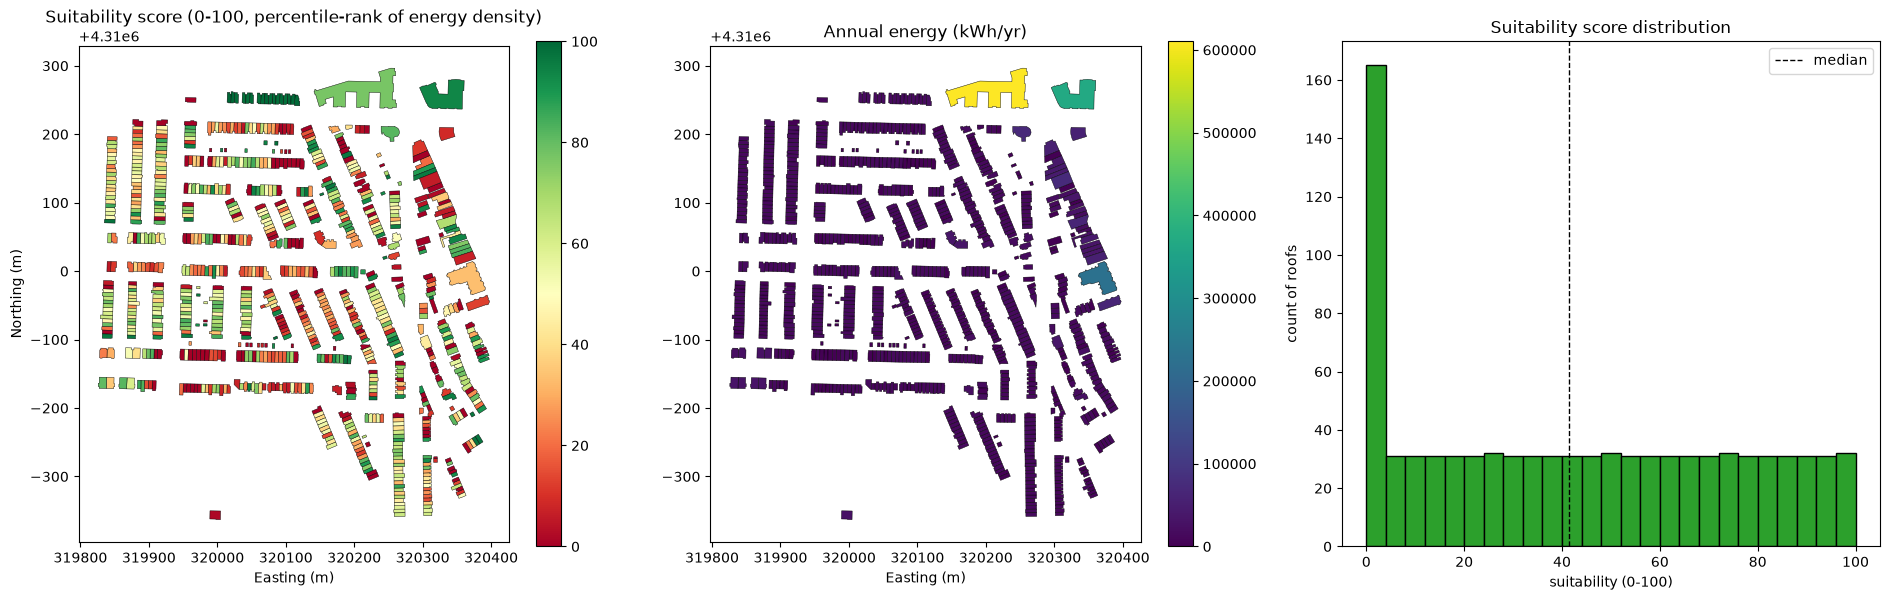

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

roofs.plot(ax=axes[0], column="suitability", cmap="RdYlGn", legend=True,
           edgecolor="black", lw=0.3, vmin=0, vmax=100)
axes[0].set_title("Suitability score (0-100, percentile-rank of energy density)")
axes[0].set_xlabel("Easting (m)"); axes[0].set_ylabel("Northing (m)")

roofs.plot(ax=axes[1], column="annual_energy_kwh", cmap="viridis", legend=True,
           edgecolor="black", lw=0.3)
axes[1].set_title("Annual energy (kWh/yr)")
axes[1].set_xlabel("Easting (m)")

axes[2].hist(roofs["suitability"], bins=25, color="tab:green", edgecolor="black")
axes[2].axvline(roofs["suitability"].median(), color="black", ls="--", lw=1, label="median")
axes[2].set_title("Suitability score distribution")
axes[2].set_xlabel("suitability (0-100)"); axes[2].set_ylabel("count of roofs"); axes[2].legend()

plt.tight_layout(); plt.show()

In [7]:
SUITABILITY_TIERS = [
    ("unusable", lambda s, ua: ua <= 0),
    ("low", lambda s, ua: (ua > 0) & (s < 33.0)),
    ("medium", lambda s, ua: (ua > 0) & (s >= 33.0) & (s < 66.0)),
    ("high", lambda s, ua: (ua > 0) & (s >= 66.0)),
]

total_usable_area_m2 = roofs["usable_area_m2"].sum()
total_capacity_kw = roofs["capacity_kw"].sum()
total_energy_mwh = roofs["annual_energy_kwh"].sum() / 1000.0
total_co2_t = roofs["annual_co2_kg"].sum() / 1000.0

print("=== AOI headline totals (stage 5-6, tiny buffered AOI) ===")
print(f"  roofs scored              : {len(roofs)}")
print(f"  total usable area         : {total_usable_area_m2:8.0f}  m2")
print(f"  total installed capacity  : {total_capacity_kw:8.1f}  kW")
print(f"  total annual energy       : {total_energy_mwh:8.1f}  MWh/yr")
print(f"  total annual CO2 offset   : {total_co2_t:8.1f}  t/yr")
print()
print("  suitability tiers (unusable = zero usable area; else low/med/high on the 0-100 score):")
for name, cond in SUITABILITY_TIERS:
    mask = cond(roofs["suitability"].to_numpy(), roofs["usable_area_m2"].to_numpy())
    print(f"    {name:10s}: {int(mask.sum()):3d} roofs")

=== AOI headline totals (stage 5-6, tiny buffered AOI) ===
  roofs scored              : 913
  total usable area         :    50326  m2
  total installed capacity  :  10065.3  kW
  total annual energy       :  12271.6  MWh/yr
  total annual CO2 offset   :   4295.1  t/yr

  suitability tiers (unusable = zero usable area; else low/med/high on the 0-100 score):
    unusable  : 134 roofs
    low       : 257 roofs
    medium    : 257 roofs
    high      : 265 roofs


## Honest findings — assumptions ledger

This is an **order-of-magnitude estimate**, not a bankable one. Every number above rests on a
stack of Phase 1 simplifications, listed here so none of them are silently forgotten:

- **Utilization fraction (0.70 flat/sun-facing, 0.0 north-facing)** — a single blanket number per
  class, not a per-roof obstruction survey. Real chimneys, vents, HVAC units, and real setback
  geometry all vary roof to roof (stage 5).
- **Footprint area as a roof-area proxy** — no `1/cos(tilt)` correction for pitched roofs (stated
  in stage 5); mostly matters little here since `03` found this AOI's roofs are mostly flat.
- **Real-sky factor (0.75)** — one flat derate from `r.sun`'s clear-sky output to a "real" DC sky,
  not an actual NSRDB/TMY time series. The formalised pipeline replaces this with real PVWatts +
  NSRDB irradiance (still fed the *shaded* surface, per trap 4).
- **Module efficiency (0.20), performance ratio (0.80), power density (0.20 kW/m2)** — reasonable
  present-day panel/system assumptions, not a chosen product SKU or a modelled inverter/wiring loss.
- **Grid carbon intensity (0.35 kg CO2/kWh)** — a single regional constant, not hour-matched to
  when the panels actually generate.
- **Clear-sky base insolation** — `02`'s 12-mid-month-day sample, not a full 365-day run (a
  documented approximation there, inherited here).
- **Roof-plane uncertainty propagates in** — `03`'s RANSAC tilt/aspect (and its inlier-ratio /
  pixel-count confidence) feeds stage 5's classification and stage 6's yield directly. A
  low-confidence tilt/aspect (see `roofs["inlier_ratio"]`, `roofs["low_confidence"]`) means the
  usable-area class and everything downstream of it for that roof should be read with the same
  grain of salt `03` reported.

**Bottom line:** treat every kWh/CO2 number above as "roughly this, within a factor of maybe 1.5-2,
and directionally right about which roofs are better than which" — not as a quote. The formalised
pipeline (`src/rooftop_solar/usable_area.py`, `yield_pv.py`) swaps in real PVWatts/NSRDB irradiance
and, eventually, validated per-roof geometry from Phase 2's ML route.

## What this exploration established (00 -> 04)

The exploration spine is now complete, end to end, on the tiny AOI:

**footprints (01) -> DSM (01) -> shaded radiation (02) -> tilt/aspect (03) -> usable area (04) ->
PV yield + suitability (04)** — the same chain `00_pipeline_overview` walked by hand on one toy
roof, now run for real across every roof in the AOI, with each of the four shading traps (risks
§8) demonstrated concretely along the way.

**What's next:** formalise this into `src/rooftop_solar/` (`usable_area.py`, `yield_pv.py`, plus
the stage 1-4 modules the earlier notebooks map to) at full **Glover Park** scale, on the
`stage-1` branch — and benchmark the result against **Esri's "Estimate solar power potential"**
tutorial, the project's chosen reference point (see `CLAUDE.md`).